[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/workshops/workshop-07-arbol-decision-clasificacion-cancer-mama.ipynb)


# Taller de clasificación con Árbol de Decisión usando Entropía

## Ejercicio propuesto

En este taller se construirá un modelo de **clasificación** con un conjunto de datos diferente al ejercicio anterior.

Se utilizará el conjunto de datos **Breast Cancer Wisconsin (Diagnostic)** incluido en `scikit-learn`.

### Objetivo

Predecir el diagnóstico de una observación a partir de **dos variables independientes**:

- **Área media (`mean area`)**
- **Promedio de puntos cóncavos (`mean concave points`)**

La variable dependiente será:

- **Diagnóstico**
  - `0 = Maligno`
  - `1 = Benigno`

El modelo utilizado será un **Árbol de Decisión** con criterio de **entropía**.

### Requisitos de la tarea

Este notebook incluye:

1. Dos variables independientes.
2. Una variable dependiente.
3. Gráfica de los datos.
4. Árbol de decisión con **entropía**.
5. Frontera de decisión.
6. Evaluación del modelo.
7. Al menos **tres predicciones**.
8. Argumentación de por qué el resultado es adecuado.



> **Nota:** este ejercicio es académico y utiliza un conjunto de datos público para aprendizaje de Machine Learning. No corresponde a una herramienta de diagnóstico médico.


## 1. Importar las librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", None)



## 2. Cargar el conjunto de datos

El conjunto de datos ya viene incluido dentro de `scikit-learn`, por lo que no es necesario descargar archivos externos.

Contiene características numéricas calculadas a partir de imágenes digitalizadas de masas mamarias.


In [2]:

cancer = load_breast_cancer()

dataset = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

dataset["diagnostico"] = cancer.target

print("Dimensiones del conjunto de datos:", dataset.shape)
print("\nClases de la variable objetivo:")
print("0 =", cancer.target_names[0])
print("1 =", cancer.target_names[1])

display(dataset.head())


Dimensiones del conjunto de datos: (569, 31)

Clases de la variable objetivo:
0 = malignant
1 = benign


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



## 3. Seleccionar las variables

Para cumplir exactamente con la tarea se utilizarán únicamente **dos variables independientes**:

$$
X_1 = \text{mean area}
$$

$$
X_2 = \text{mean concave points}
$$

y una variable dependiente:

$$
Y = \text{diagnóstico}
$$

Estas dos variables son numéricas y permiten representar el problema gráficamente en dos dimensiones.


In [3]:

variables_x = ["mean area", "mean concave points"]
variable_y = "diagnostico"

X = dataset[variables_x].copy()
y = dataset[variable_y].copy()

print("Variables independientes:")
print(variables_x)

print("\nVariable dependiente:")
print(variable_y)

print("\nValores faltantes:")
display(dataset[variables_x + [variable_y]].isnull().sum().to_frame("Cantidad"))

display(dataset[variables_x + [variable_y]].head())


Variables independientes:
['mean area', 'mean concave points']

Variable dependiente:
diagnostico

Valores faltantes:


,Cantidad
mean area,0
mean concave points,0
diagnostico,0


,mean area,mean concave points,diagnostico
0,1001.0,0.14710,0
1,1326.0,0.07017,0
2,1203.0,0.12790,0
3,386.1,0.10520,0
4,1297.0,0.10430,0


## 4. Explorar la distribución de las clases

,Clase,Cantidad
0,Maligno,212
1,Benigno,357


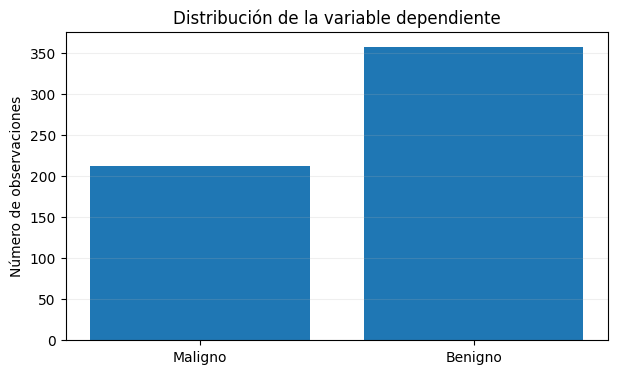

In [4]:

conteo = y.value_counts().sort_index()

resumen_clases = pd.DataFrame({
    "Clase": ["Maligno", "Benigno"],
    "Cantidad": [conteo.get(0, 0), conteo.get(1, 0)]
})

display(resumen_clases)

plt.figure(figsize=(7, 4))
plt.bar(resumen_clases["Clase"], resumen_clases["Cantidad"])
plt.ylabel("Número de observaciones")
plt.title("Distribución de la variable dependiente")
plt.grid(axis="y", alpha=0.2)
plt.show()



## 5. Gráfica de las dos variables independientes

Cada punto representa una observación del conjunto de datos.

La posición depende de las dos variables independientes y la clase corresponde al diagnóstico real.

Esta gráfica permite comprobar visualmente si existen zonas donde los diagnósticos tienden a separarse.


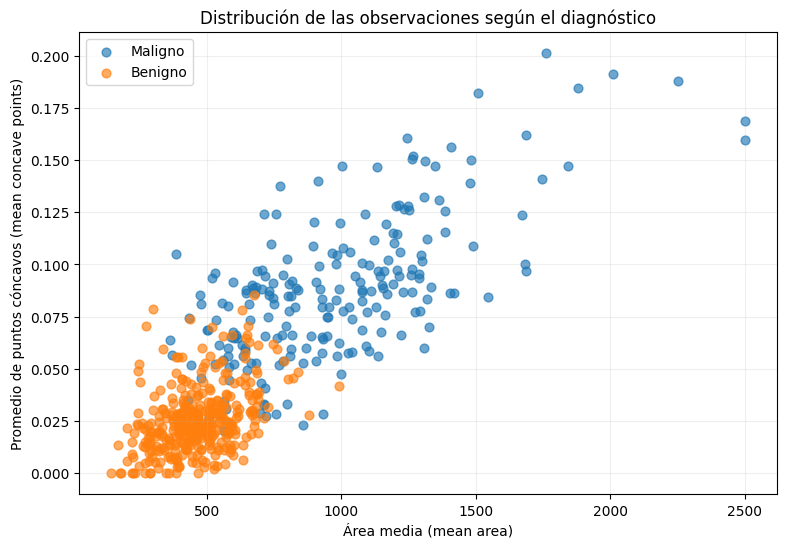

In [5]:

plt.figure(figsize=(9, 6))

for clase, nombre in [(0, "Maligno"), (1, "Benigno")]:
    mascara = y == clase
    plt.scatter(
        X.loc[mascara, "mean area"],
        X.loc[mascara, "mean concave points"],
        s=40,
        alpha=0.65,
        label=nombre
    )

plt.xlabel("Área media (mean area)")
plt.ylabel("Promedio de puntos cóncavos (mean concave points)")
plt.title("Distribución de las observaciones según el diagnóstico")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



## 6. Dividir los datos en entrenamiento y prueba

Se utilizará:

- **75 %** para entrenamiento.
- **25 %** para prueba.

El conjunto de prueba contiene observaciones que el modelo no utiliza durante el entrenamiento. Esto permite evaluar si el árbol puede clasificar datos nuevos.

`stratify=y` mantiene una proporción similar de las dos clases en ambos conjuntos.


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])


Datos de entrenamiento: 426
Datos de prueba: 143



## 7. Construir el Árbol de Decisión usando Entropía

El criterio solicitado en la tarea es **entropía**.

La entropía mide el grado de mezcla o incertidumbre de las clases en un nodo:

$$
H = -\sum_{i=1}^{k}p_i\log_2(p_i)
$$

En un problema binario:

$$
H = -p_0\log_2(p_0)-p_1\log_2(p_1)
$$

### Interpretación

- Si un nodo contiene una sola clase, su entropía es **0**.
- Si las clases están muy mezcladas, la entropía aumenta.
- El árbol busca divisiones que reduzcan la entropía y formen grupos más puros.

Se limita la profundidad del árbol para mantenerlo interpretable y reducir el riesgo de sobreajuste.


In [7]:

modelo = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print("Criterio:", modelo.criterion)
print("Profundidad del árbol:", modelo.get_depth())
print("Número de hojas:", modelo.get_n_leaves())


Modelo entrenado.
Criterio: entropy
Profundidad del árbol: 4
Número de hojas: 9


## 8. Visualizar el árbol

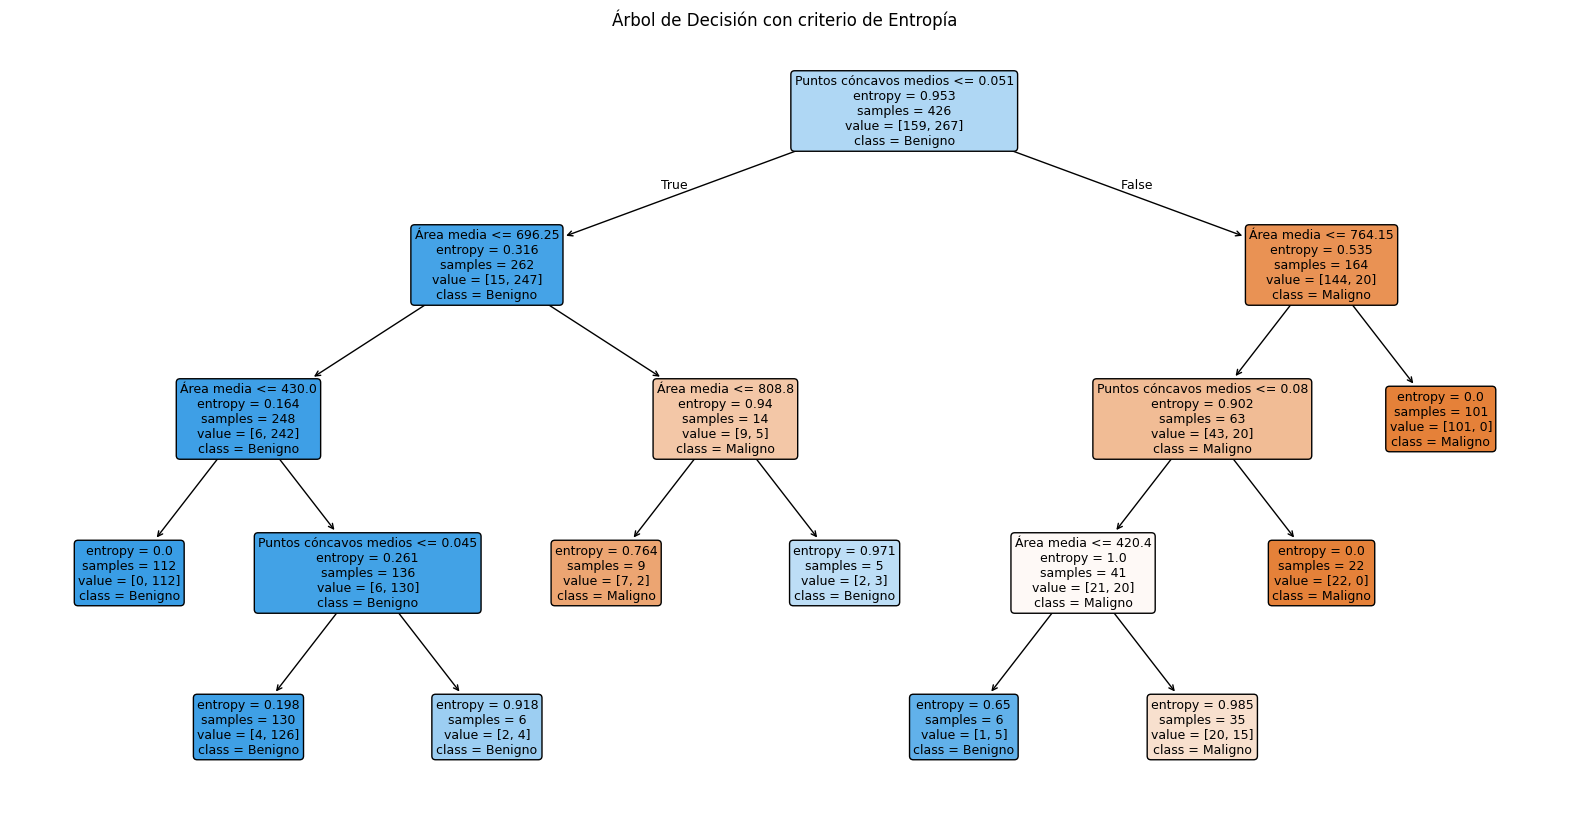

In [8]:

plt.figure(figsize=(20, 10))

plot_tree(
    modelo,
    feature_names=[
        "Área media",
        "Puntos cóncavos medios"
    ],
    class_names=[
        "Maligno",
        "Benigno"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de Decisión con criterio de Entropía")
plt.show()



### ¿Cómo se interpreta el árbol?

Cada nodo muestra una regla como:

$$
\text{Área media} \leq \text{valor}
$$

o

$$
\text{Puntos cóncavos medios} \leq \text{valor}
$$

También aparecen:

- **entropy:** nivel de impureza del nodo.
- **samples:** número de observaciones.
- **value:** cantidad de casos de cada clase.
- **class:** clase que predomina.

El árbol intenta llegar a hojas con una mezcla cada vez menor de las dos clases.


## 9. Realizar las predicciones del conjunto de prueba

In [9]:

y_pred = modelo.predict(X_test)

accuracy_train = accuracy_score(y_train, modelo.predict(X_train))
accuracy_test = accuracy_score(y_test, y_pred)

print(f"Exactitud en entrenamiento: {accuracy_train:.2%}")
print(f"Exactitud en prueba:        {accuracy_test:.2%}")
print(f"Diferencia:                 {abs(accuracy_train - accuracy_test):.2%}")


Exactitud en entrenamiento: 93.90%
Exactitud en prueba:        91.61%
Diferencia:                 2.29%


## 10. Matriz de confusión

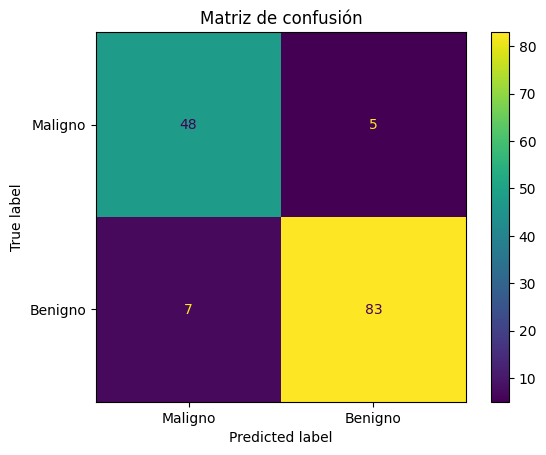

In [10]:

matriz = confusion_matrix(y_test, y_pred)

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Maligno", "Benigno"]
)

display_matriz.plot()
plt.title("Matriz de confusión")
plt.show()


In [11]:

print("Reporte de clasificación:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Maligno", "Benigno"],
        zero_division=0
    )
)


Reporte de clasificación:

              precision    recall  f1-score   support

     Maligno       0.87      0.91      0.89        53
     Benigno       0.94      0.92      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143




## 11. Gráfica de la frontera de decisión

Esta gráfica muestra cómo el árbol divide el espacio formado por las dos variables independientes.

El **fondo** representa la clase que el modelo asignaría a cada combinación de valores.

Los **puntos** corresponden a las observaciones reales del conjunto de prueba.

Es normal que un Árbol de Decisión genere regiones con forma rectangular, porque cada división se realiza aplicando un umbral sobre una variable a la vez.


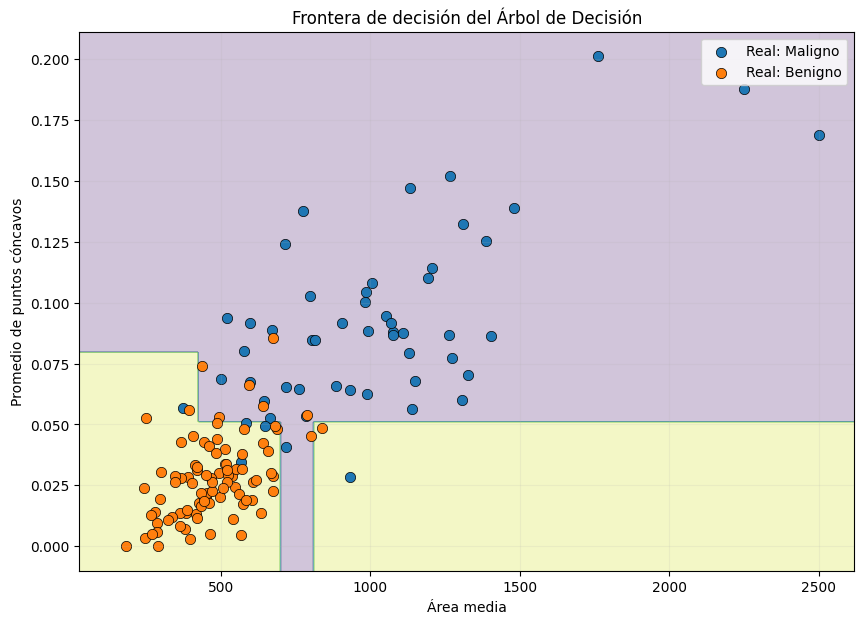

In [12]:

x1_min = X["mean area"].min()
x1_max = X["mean area"].max()

x2_min = X["mean concave points"].min()
x2_max = X["mean concave points"].max()

margen_x1 = (x1_max - x1_min) * 0.05
margen_x2 = (x2_max - x2_min) * 0.05

x1_vals = np.linspace(
    x1_min - margen_x1,
    x1_max + margen_x1,
    350
)

x2_vals = np.linspace(
    x2_min - margen_x2,
    x2_max + margen_x2,
    350
)

X1, X2 = np.meshgrid(x1_vals, x2_vals)

malla_df = pd.DataFrame({
    "mean area": X1.ravel(),
    "mean concave points": X2.ravel()
})

Z = modelo.predict(malla_df).reshape(X1.shape)

plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, Z, alpha=0.25)

for clase, nombre in [(0, "Maligno"), (1, "Benigno")]:
    mascara = y_test == clase

    plt.scatter(
        X_test.loc[mascara, "mean area"],
        X_test.loc[mascara, "mean concave points"],
        s=55,
        edgecolor="black",
        linewidth=0.5,
        label=f"Real: {nombre}"
    )

plt.xlabel("Área media")
plt.ylabel("Promedio de puntos cóncavos")
plt.title("Frontera de decisión del Árbol de Decisión")
plt.legend()
plt.grid(alpha=0.15)
plt.show()



## 12. Tres predicciones

Para cumplir el requisito de la tarea se tomarán **tres observaciones del conjunto de prueba**, que el modelo no utilizó durante su entrenamiento.

Para cada una se mostrará:

- valor de las dos variables independientes;
- diagnóstico real;
- diagnóstico predicho;
- probabilidad estimada por el modelo.


In [13]:

tres_casos = X_test.iloc[:3].copy()
reales = y_test.iloc[:3].to_numpy()

pred_tres = modelo.predict(tres_casos)
prob_tres = modelo.predict_proba(tres_casos)

nombres_clase = {
    0: "Maligno",
    1: "Benigno"
}

resultados = tres_casos.reset_index(drop=True).copy()
resultados["Diagnóstico real"] = [nombres_clase[v] for v in reales]
resultados["Predicción"] = [nombres_clase[v] for v in pred_tres]
resultados["Probabilidad maligno"] = prob_tres[:, 0]
resultados["Probabilidad benigno"] = prob_tres[:, 1]
resultados["¿Correcta?"] = np.where(reales == pred_tres, "Sí", "No")

display(resultados)


,mean area,mean concave points,Diagnóstico real,Predicción,Probabilidad maligno,Probabilidad benigno,¿Correcta?
0,493.8,0.02995,Benigno,Benigno,0.030769,0.969231,Sí
1,991.7,0.08824,Maligno,Maligno,1.000000,0.000000,Sí
2,687.3,0.04819,Benigno,Benigno,0.333333,0.666667,Sí


In [14]:

print("INTERPRETACIÓN DE LAS TRES PREDICCIONES\n")

for i in range(3):
    print(f"Predicción {i + 1}")
    print(f"  Área media: {resultados.loc[i, 'mean area']:.3f}")
    print(
        "  Puntos cóncavos medios: "
        f"{resultados.loc[i, 'mean concave points']:.5f}"
    )
    print(f"  Valor real: {resultados.loc[i, 'Diagnóstico real']}")
    print(f"  Predicción: {resultados.loc[i, 'Predicción']}")
    print(f"  ¿Fue correcta?: {resultados.loc[i, '¿Correcta?']}")
    print()


INTERPRETACIÓN DE LAS TRES PREDICCIONES

Predicción 1
  Área media: 493.800
  Puntos cóncavos medios: 0.02995
  Valor real: Benigno
  Predicción: Benigno
  ¿Fue correcta?: Sí

Predicción 2
  Área media: 991.700
  Puntos cóncavos medios: 0.08824
  Valor real: Maligno
  Predicción: Maligno
  ¿Fue correcta?: Sí

Predicción 3
  Área media: 687.300
  Puntos cóncavos medios: 0.04819
  Valor real: Benigno
  Predicción: Benigno
  ¿Fue correcta?: Sí



## 13. Mostrar las tres predicciones en la gráfica

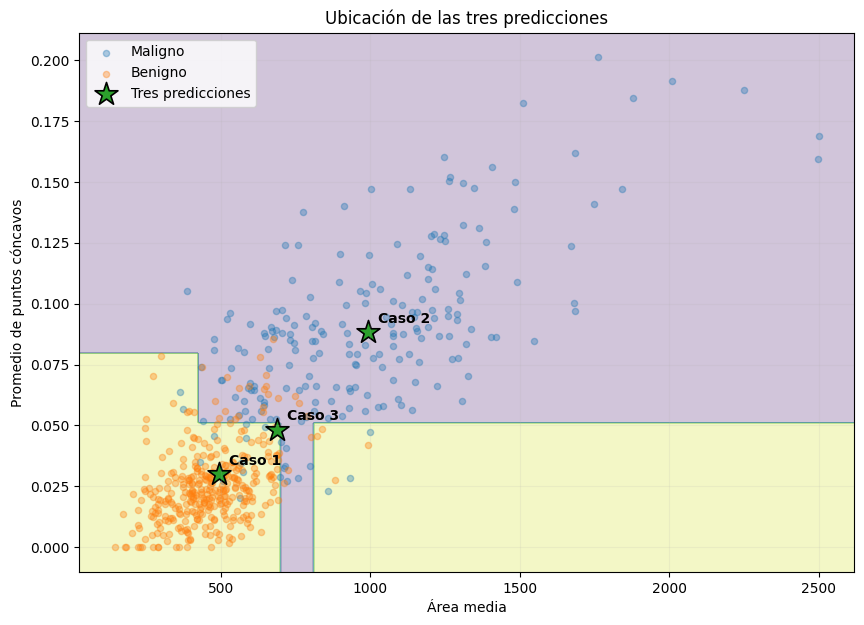

In [15]:

plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, Z, alpha=0.25)

# Todos los datos
for clase, nombre in [(0, "Maligno"), (1, "Benigno")]:
    mascara = y == clase
    plt.scatter(
        X.loc[mascara, "mean area"],
        X.loc[mascara, "mean concave points"],
        s=20,
        alpha=0.35,
        label=nombre
    )

# Tres casos seleccionados
plt.scatter(
    tres_casos["mean area"],
    tres_casos["mean concave points"],
    marker="*",
    s=300,
    edgecolor="black",
    linewidth=1.2,
    label="Tres predicciones"
)

for i, (_, fila) in enumerate(tres_casos.iterrows(), start=1):
    plt.annotate(
        f"Caso {i}",
        (fila["mean area"], fila["mean concave points"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontweight="bold"
    )

plt.xlabel("Área media")
plt.ylabel("Promedio de puntos cóncavos")
plt.title("Ubicación de las tres predicciones")
plt.legend()
plt.grid(alpha=0.15)
plt.show()


## 14. Importancia de las dos variables

,Variable,Importancia
1,Puntos cóncavos medios,0.786758
0,Área media,0.213242


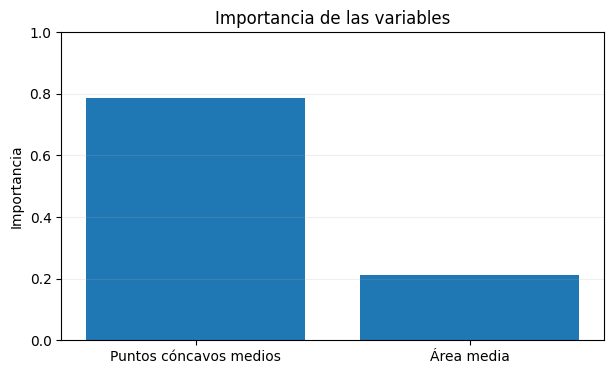

In [16]:

importancias = pd.DataFrame({
    "Variable": [
        "Área media",
        "Puntos cóncavos medios"
    ],
    "Importancia": modelo.feature_importances_
}).sort_values("Importancia", ascending=False)

display(importancias)

plt.figure(figsize=(7, 4))
plt.bar(
    importancias["Variable"],
    importancias["Importancia"]
)
plt.ylabel("Importancia")
plt.title("Importancia de las variables")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.2)
plt.show()



## 15. Argumentación: ¿por qué el modelo está bien?

Para justificar el ejercicio no basta con decir que la gráfica “se ve bien”. La argumentación debe considerar:

1. El desempeño sobre datos que el árbol **no utilizó para entrenarse**.
2. La matriz de confusión.
3. La diferencia entre exactitud de entrenamiento y prueba.
4. La forma de la frontera de decisión.
5. La capacidad del modelo para realizar predicciones nuevas.

La siguiente celda genera una conclusión a partir de los resultados obtenidos.


In [17]:

diferencia = abs(accuracy_train - accuracy_test)
correctas = int((y_pred == y_test).sum())
total_prueba = len(y_test)

if accuracy_test >= 0.90:
    evaluacion = "alta"
elif accuracy_test >= 0.80:
    evaluacion = "buena"
elif accuracy_test >= 0.70:
    evaluacion = "moderada"
else:
    evaluacion = "limitada"

if diferencia <= 0.10:
    texto_sobreajuste = (
        "La diferencia entre entrenamiento y prueba es pequeña, "
        "por lo que no se observa una señal fuerte de sobreajuste."
    )
else:
    texto_sobreajuste = (
        "La diferencia entre entrenamiento y prueba es considerable, "
        "por lo que sería conveniente revisar la complejidad del árbol."
    )

print("ARGUMENTACIÓN FINAL\n")

print(
    f"El árbol alcanzó una exactitud de {accuracy_test:.2%} en el conjunto "
    f"de prueba, clasificando correctamente {correctas} de {total_prueba} "
    f"observaciones. Para este ejercicio, el desempeño puede considerarse "
    f"{evaluacion}."
)

print()
print(
    f"La exactitud de entrenamiento fue {accuracy_train:.2%}. "
    f"{texto_sobreajuste}"
)

print()
print(
    "La matriz de confusión permite observar de manera concreta cuáles "
    "observaciones fueron clasificadas correctamente y cuáles fueron confundidas."
)

print()
print(
    "La frontera de decisión también es coherente con un Árbol de Decisión: "
    "se observan regiones rectangulares producidas por cortes sucesivos sobre "
    "las dos variables independientes."
)

print()
print(
    "Además, el modelo produjo tres predicciones sobre observaciones que no "
    "participaron en el entrenamiento, mostrando tanto la clase predicha "
    "como las probabilidades estimadas."
)

print()
print(
    "Por estas razones, el ejercicio cumple con el objetivo de construir "
    "un clasificador interpretable utilizando dos variables independientes, "
    "una variable dependiente y el criterio de entropía."
)


ARGUMENTACIÓN FINAL

El árbol alcanzó una exactitud de 91.61% en el conjunto de prueba, clasificando correctamente 131 de 143 observaciones. Para este ejercicio, el desempeño puede considerarse alta.

La exactitud de entrenamiento fue 93.90%. La diferencia entre entrenamiento y prueba es pequeña, por lo que no se observa una señal fuerte de sobreajuste.

La matriz de confusión permite observar de manera concreta cuáles observaciones fueron clasificadas correctamente y cuáles fueron confundidas.

La frontera de decisión también es coherente con un Árbol de Decisión: se observan regiones rectangulares producidas por cortes sucesivos sobre las dos variables independientes.

Además, el modelo produjo tres predicciones sobre observaciones que no participaron en el entrenamiento, mostrando tanto la clase predicha como las probabilidades estimadas.

Por estas razones, el ejercicio cumple con el objetivo de construir un clasificador interpretable utilizando dos variables independientes, una va


# Conclusión para entregar

En este ejercicio se desarrolló un modelo de **clasificación binaria** mediante un **Árbol de Decisión**. Se utilizaron dos variables independientes, **área media** y **promedio de puntos cóncavos**, para predecir una variable dependiente correspondiente al diagnóstico.

El árbol fue construido con el criterio de **entropía**, que selecciona las divisiones que disminuyen la incertidumbre de las clases. El desempeño se evaluó utilizando un conjunto de prueba separado del conjunto de entrenamiento, mediante exactitud, matriz de confusión y reporte de clasificación.

La frontera de decisión muestra de manera gráfica cómo el árbol separa las observaciones en regiones. La forma rectangular de estas regiones es coherente con el funcionamiento del algoritmo, ya que el árbol realiza divisiones mediante umbrales sobre una variable a la vez.

Finalmente, se presentaron **tres predicciones** sobre observaciones del conjunto de prueba, comparando el diagnóstico real con el diagnóstico estimado por el modelo.

Por lo tanto, el ejercicio cumple con los requisitos planteados: **dos variables independientes, una variable dependiente, gráfica, argumentación, mínimo tres predicciones y uso de entropía**.
